In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

In [3]:
# прочитаем наши данные из файла users и запишем в переменную
df = pd.read_csv('C:/Users/majkl/WorkSpace/Analysis_AB_test_new_system_on_sales/ab_test_data.csv')
# выведем инофрмацию о датафрейме
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2000 non-null   int64  
 1   group    2000 non-null   object 
 2   spend    2000 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 47.0+ KB


,user_id,group,spend
0,1,A,2897.37
1,2,A,2389.39
2,3,A,3018.15
3,4,A,3718.42
4,5,A,2312.68


In [4]:
# поиск дублей записей
print(df.isnull().sum())

user_id    0
group      0
spend      0
dtype: int64


##### Дублей не обнаружено, записи в нужном виде для анализа.

### СТАТИСТИКА ПО ГРУППАМ:

In [7]:
# Статистики для группы A
group_a_spends = df[df['group'] == 'A']['spend'].values

mean_a = np.mean(group_a_spends)
median_a = np.median(group_a_spends)
std_a = np.std(group_a_spends, ddof=1)

print(f"Группа A (старая система):")
print(f"  Среднее: {mean_a:.2f} руб")
print(f"  Медиана: {median_a:.2f} руб")
print(f"  Стандартное отклонение: {std_a:.2f} руб")
print(f"  Размер группы: {len(group_a_spends)} пользователей")

Группа A (старая система):
  Среднее: 2515.65 руб
  Медиана: 2520.24 руб
  Стандартное отклонение: 782.77 руб
  Размер группы: 1000 пользователей


In [8]:
# Статистики для группы B
group_b_spends = df[df['group'] == 'B']['spend'].values

mean_b = np.mean(group_b_spends)
median_b = np.median(group_b_spends)
std_b = np.std(group_b_spends, ddof=1)

print(f"\nГруппа B (новая система):")
print(f"  Среднее: {mean_b:.2f} руб")
print(f"  Медиана: {median_b:.2f} руб")
print(f"  Стандартное отклонение: {std_b:.2f} руб")
print(f"  Размер группы: {len(group_b_spends)} пользователей")


Группа B (новая система):
  Среднее: 2706.67 руб
  Медиана: 2700.46 руб
  Стандартное отклонение: 797.96 руб
  Размер группы: 1000 пользователей


In [12]:
# Разница между группами
mean_diff = mean_b - mean_a
print(f"РАЗНИЦА МЕЖДУ ГРУППАМИ:")
print(f"B - A = {mean_diff:.2f} руб")
print(f"Относительное изменение: {(mean_diff/mean_a)*100:.1f}%")

РАЗНИЦА МЕЖДУ ГРУППАМИ:
B - A = 191.02 руб
Относительное изменение: 7.6%


### ИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ

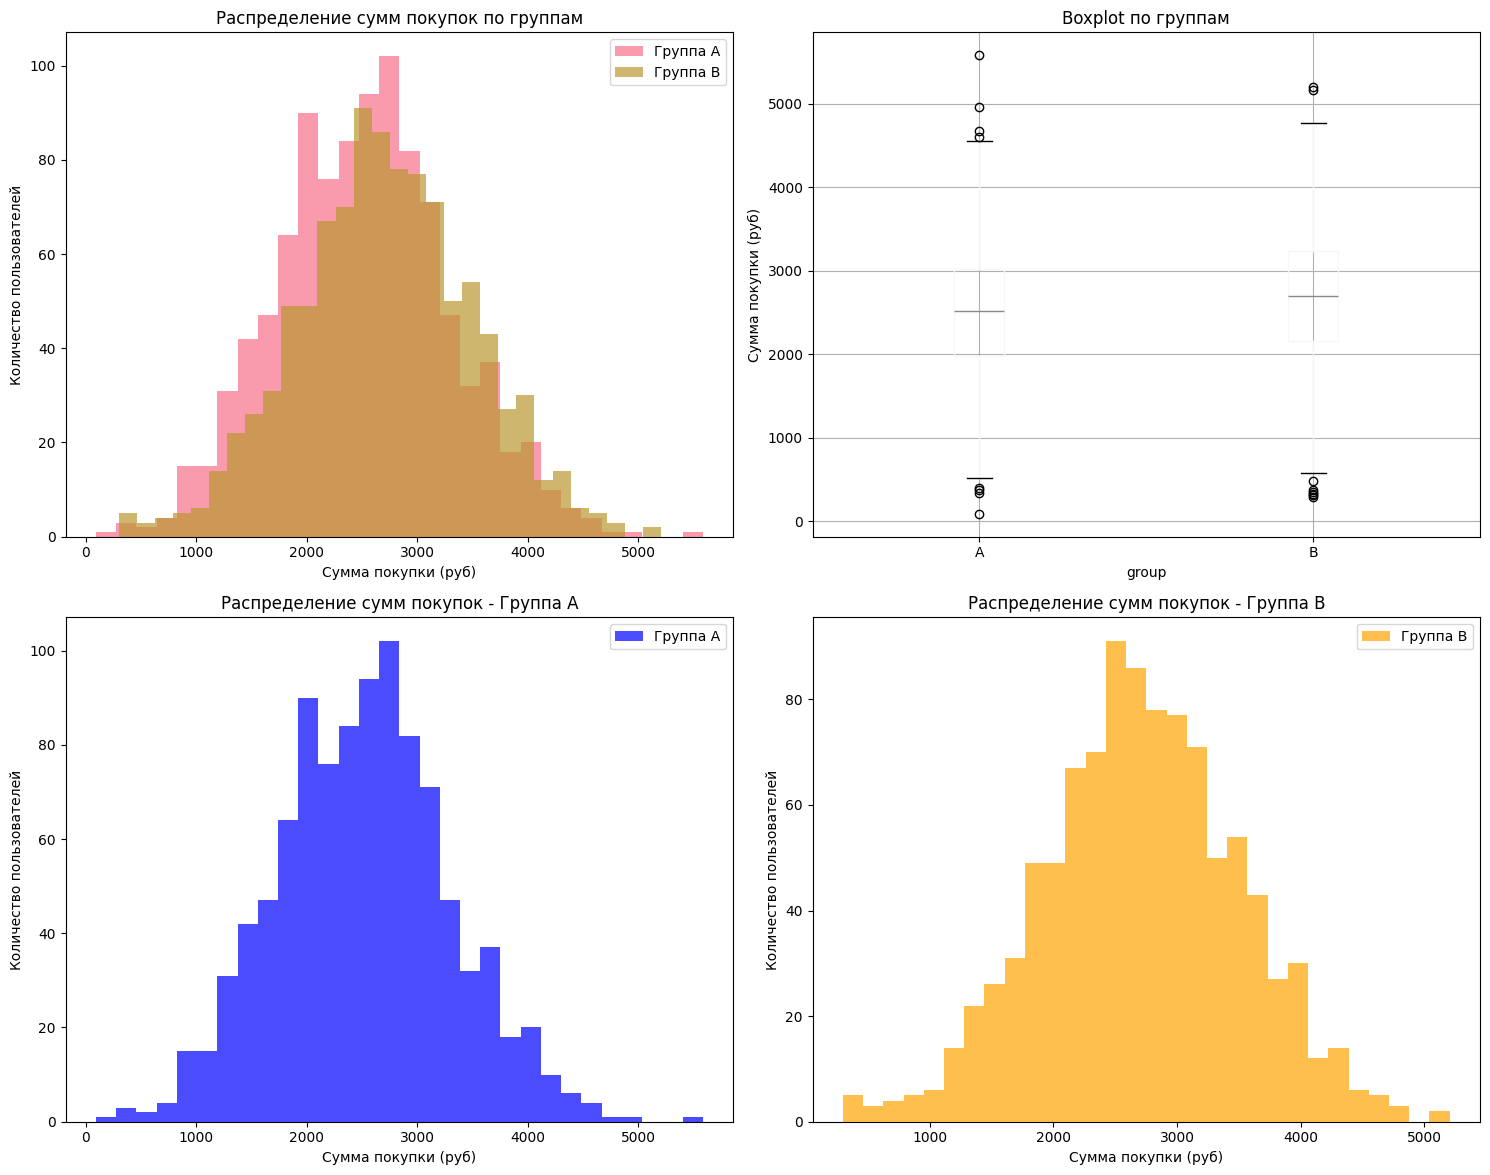

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Гистограмма обеих групп
axes[0, 0].hist(group_a_spends, bins=30, alpha=0.7, label='Группа A')
axes[0, 0].hist(group_b_spends, bins=30, alpha=0.7, label='Группа B')
axes[0, 0].set_xlabel('Сумма покупки (руб)')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].set_title('Распределение сумм покупок по группам')
axes[0, 0].legend()

# Boxplot
df.boxplot(column='spend', by='group', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot по группам')
axes[0, 1].set_ylabel('Сумма покупки (руб)')

# Гистограмма группы A
axes[1, 0].hist(group_a_spends, bins=30, alpha=0.7, color='blue', label='Группа A')
axes[1, 0].set_xlabel('Сумма покупки (руб)')
axes[1, 0].set_ylabel('Количество пользователей')
axes[1, 0].set_title('Распределение сумм покупок - Группа A')
axes[1, 0].legend()

# Гистограмма группы B
axes[1, 1].hist(group_b_spends, bins=30, alpha=0.7, color='orange', label='Группа B')
axes[1, 1].set_xlabel('Сумма покупки (руб)')
axes[1, 1].set_ylabel('Количество пользователей')
axes[1, 1].set_title('Распределение сумм покупок - Группа B')
axes[1, 1].legend()

# Убираем автоматическое название от boxplot
plt.suptitle('')

plt.tight_layout()
plt.show()

### ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ (T-ТЕСТ)

In [20]:
# Проводим t-тест для независимых выборок
t_stat, p_value = stats.ttest_ind(group_b_spends, group_a_spends, equal_var=False)

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Интерпретация результата
alpha = 0.05  # уровень значимости 5%
print(f"\nУровень значимости (alpha): {alpha}")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Статистически значимые различия ЕСТЬ")
    print("Новая система рекомендаций ДЕЙСТВИТЕЛЬНО влияет на средний чек")
else:
    print("РЕЗУЛЬТАТ: Статистически значимых различий НЕТ")
    print("Новая система рекомендаций НЕ влияет на средний чек")

t-статистика: 5.4039
p-value: 0.0000

Уровень значимости (alpha): 0.05
РЕЗУЛЬТАТ: Статистически значимые различия ЕСТЬ
Новая система рекомендаций ДЕЙСТВИТЕЛЬНО влияет на средний чек


In [ ]:
# Доверительный интервал для разницы средних
sample_size = 1000

def confidence_interval_mean_diff(mean1, mean2, std1, std2, n1, n2, confidence=0.95):
    """Расчет доверительного интервала для разницы средних"""
    # Стандартная ошибка разницы средних
    se = math.sqrt((std1**2 / n1) + (std2**2 / n2))
    
    # t-критическое значение для 95% доверительного интервала
    t_critical = stats.t.ppf((1 + confidence) / 2, df=min(n1-1, n2-1))
    
    # Разница средних
    mean_diff = mean1 - mean2
    
    # Границы доверительного интервала
    margin_of_error = t_critical * se
    ci_lower = mean_diff - margin_of_error
    ci_upper = mean_diff + margin_of_error
    
    return ci_lower, ci_upper, margin_of_error

# Расчет доверительного интервала для разницы (B - A)
ci_lower, ci_upper, margin = confidence_interval_mean_diff(
    mean_b, mean_a, std_b, std_a, sample_size, sample_size
)

print(f"Доверительный интервал 95% для разницы (B - A):")
print(f"  Нижняя граница: {ci_lower:.2f} руб")
print(f"  Верхняя граница: {ci_upper:.2f} руб")
print(f"  Ширина интервала: {ci_upper - ci_lower:.2f} руб")


Доверительный интервал 95% для разницы (B - A):
  Нижняя граница: 121.65 руб
  Верхняя граница: 260.38 руб
  Ширина интервала: 138.73 руб


### Выводы

In [31]:
print(f"1. Новая система увеличила средний чек на {mean_diff:.2f} руб ({(mean_diff/mean_a)*100:.1f}%)")
print(f"2. Статистическая значимость: p-value = {p_value:.4f} {'< 0.05' if p_value < 0.05 else '> 0.05'}")
print(f"3. Мы на 95% уверены, что истинный эффект находится в интервале: [{ci_lower:.2f}, {ci_upper:.2f}] руб")

if p_value < 0.05 and ci_lower > 0:
    print("4. РЕКОМЕНДАЦИЯ: Внедрить новую систему рекомендаций по всем пользователям")
else:
    print("4. РЕКОМЕНДАЦИЯ: Продолжить тестирование или доработать систему")

1. Новая система увеличила средний чек на 191.02 руб (7.6%)
2. Статистическая значимость: p-value = 0.0000 < 0.05
3. Мы на 95% уверены, что истинный эффект находится в интервале: [121.65, 260.38] руб
4. РЕКОМЕНДАЦИЯ: Внедрить новую систему рекомендаций по всем пользователям
